## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from itertools import product
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from kneed import KneeLocator

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

## Set Random Seed and Device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch device:", DEVICE)

PyTorch device: cuda


## Define Project Paths

In [3]:
ROOT_DIR = Path.cwd().parent.parent

DATA_DIR = (
    ROOT_DIR /
    "results" /
    "module_2" /
    "dataset_creation"
)

RESULTS_DIR = (
    ROOT_DIR /
    "results" /
    "module_2" /
    "5.vae_dbscan_tuning"
)

PLOTS_DIR = (
    ROOT_DIR /
    "plots" /
    "module_2" /
    "5.vae_dbscan_tuning"
)

EMBEDDINGS_DIR = (
    RESULTS_DIR /
    "embeddings"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EMBEDDINGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Plots directory:", PLOTS_DIR)
print("Embeddings directory:", EMBEDDINGS_DIR)

Data directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning
Plots directory: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\5.vae_dbscan_tuning
Embeddings directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\embeddings


## Load the Clustering Dataset

In [4]:
DATA_FILE = (
    DATA_DIR /
    "clustering_dataset_scaled.csv"
)

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (7859, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,0.0,0.271546,0.077035,0.055777,0.283237,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,165269,0.486111,1.0,0.267434,0.057636,0.143426,0.364162,0.042126,0.410714,0.219512,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,0.0,0.254770,0.061000,0.183267,0.410405,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,0.0,0.275658,0.075577,0.039841,0.705202,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,215156,0.680556,0.0,0.250658,0.065598,0.135458,0.398844,0.013386,0.464286,0.390244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Define Patient Identifier and Feature Matrix

In [5]:
ID_COLUMN = "patientunitstayid"

patient_ids = df[ID_COLUMN].copy()

X_df = df.drop(
    columns=[ID_COLUMN]
).copy()

X = X_df.to_numpy(
    dtype=np.float32
)

print("Number of patients:", X.shape[0])
print("Number of clustering features:", X.shape[1])

Number of patients: 7859
Number of clustering features: 80


## Verify the Dataset

In [6]:
print("Dataset verification")
print("=" * 60)

print("Number of patients:", len(df))
print(
    "Unique patients:",
    df[ID_COLUMN].nunique()
)

print(
    "Duplicate patient IDs:",
    df[ID_COLUMN].duplicated().sum()
)

print(
    "Number of clustering features:",
    X.shape[1]
)

print(
    "Missing values:",
    np.isnan(X).sum()
)

print(
    "Infinite values:",
    np.isinf(X).sum()
)

print(
    "Minimum feature value:",
    X.min()
)

print(
    "Maximum feature value:",
    X.max()
)

Dataset verification
Number of patients: 7859
Unique patients: 7859
Duplicate patient IDs: 0
Number of clustering features: 80
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0


## Confirm All Features are Numeric

In [7]:
non_numeric_columns = X_df.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if len(non_numeric_columns) == 0:
    print(
        "All clustering features are numeric."
    )
else:
    print(
        "Non-numeric columns found:"
    )
    print(non_numeric_columns)

All clustering features are numeric.


## Define VAE + DBSCAN Hyperparameters

In [8]:
# VAE hidden-layer architectures
vae_hidden_configs = [
    (128, 64),
    (256, 128),
]

# Keep latent space two-dimensional for direct comparison with t-SNE and UMAP
latent_dim_values = [
    2
]

# Learning rates 
learning_rate_values = [
    0.0001,
    0.0002,
    0.0003,
    0.0004,
    0.0005,
    0.0006,
    0.0007,
    0.0008,
    0.0009,
    0.0010
]

# KL-divergence weighting
beta_values = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25
]

# Fixed for fair comparison
batch_size_values = [
    128
]

epoch_values = [
    100
]

# DBSCAN MinPts Covers the paper-centered region your previously promising higher values
min_samples_values = [
    50
]

eps_values = np.round(
    np.arange(
        0.01,
        1.005,
        0.005
    ),
    3
).tolist()


print("VAE hidden configurations:")
print(vae_hidden_configs)

print("\nLatent dimensions:")
print(latent_dim_values)

print("\nLearning rates:")
print(learning_rate_values)

print("\nBeta values:")
print(beta_values)

print("\nBatch sizes:")
print(batch_size_values)

print("\nEpoch values:")
print(epoch_values)

print("\nDBSCAN MinPts:")
print(min_samples_values)

print(
    "\nNumber of epsilon grid values:",
    len(eps_values)
)

VAE hidden configurations:
[(128, 64), (256, 128)]

Latent dimensions:
[2]

Learning rates:
[0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001]

Beta values:
[0.05, 0.1, 0.15, 0.2, 0.25]

Batch sizes:
[128]

Epoch values:
[100]

DBSCAN MinPts:
[50]

Number of epsilon grid values: 199


## Convert the Dataset to a PyTorch Tensor

In [9]:
X_tensor = torch.tensor(
    X,
    dtype=torch.float32
)

vae_dataset = TensorDataset(
    X_tensor
)

INPUT_DIM = X.shape[1]

print(
    "VAE dataset prepared successfully."
)

print(
    "Number of patients:",
    len(vae_dataset)
)

print(
    "Number of input features:",
    INPUT_DIM
)

print(
    "Tensor shape:",
    X_tensor.shape
)

VAE dataset prepared successfully.
Number of patients: 7859
Number of input features: 80
Tensor shape: torch.Size([7859, 80])


## Define the VAE Architecture

In [10]:
class VAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dims,
        latent_dim
    ):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        encoder_layers = []

        previous_dim = input_dim

        for hidden_dim in hidden_dims:

            encoder_layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            encoder_layers.append(
                nn.ReLU()
            )

            previous_dim = hidden_dim

        self.encoder = nn.Sequential(
            *encoder_layers
        )

        self.fc_mu = nn.Linear(
            previous_dim,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            previous_dim,
            latent_dim
        )

        # -------------------------
        # Decoder
        # -------------------------

        decoder_layers = []

        reversed_hidden_dims = list(
            reversed(hidden_dims)
        )

        previous_dim = latent_dim

        for hidden_dim in reversed_hidden_dims:

            decoder_layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            decoder_layers.append(
                nn.ReLU()
            )

            previous_dim = hidden_dim

        decoder_layers.append(
            nn.Linear(
                previous_dim,
                input_dim
            )
        )

        # Input features are min-max scaled
        decoder_layers.append(
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            *decoder_layers
        )


    def encode(self, x):

        hidden = self.encoder(x)

        mu = self.fc_mu(hidden)

        logvar = self.fc_logvar(hidden)

        return mu, logvar


    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        epsilon = torch.randn_like(
            std
        )

        return (
            mu +
            epsilon * std
        )


    def decode(self, z):

        return self.decoder(z)


    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstructed = self.decode(z)

        return (
            reconstructed,
            mu,
            logvar
        )

## Define the VAE Loss Function

In [11]:
def vae_loss_function(
    reconstructed,
    original,
    mu,
    logvar,
    beta
):

    reconstruction_loss = F.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 +
        logvar -
        mu.pow(2) -
        logvar.exp()
    )

    total_loss = (
        reconstruction_loss +
        beta * kl_divergence
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_divergence
    )

## Define the VAE Training Function

In [12]:
def train_vae(
    hidden_dims,
    latent_dim,
    learning_rate,
    beta,
    batch_size,
    epochs
):

    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        vae_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    model = VAE(
        input_dim=INPUT_DIM,
        hidden_dims=hidden_dims,
        latent_dim=latent_dim
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = []

    model.train()

    for epoch in range(
        1,
        epochs + 1
    ):

        total_epoch_loss = 0
        total_reconstruction = 0
        total_kl = 0

        for (batch_x,) in train_loader:

            batch_x = batch_x.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            reconstructed, mu, logvar = (
                model(batch_x)
            )

            (
                loss,
                reconstruction_loss,
                kl_divergence
            ) = vae_loss_function(
                reconstructed,
                batch_x,
                mu,
                logvar,
                beta
            )

            loss.backward()

            optimizer.step()

            total_epoch_loss += (
                loss.item()
            )

            total_reconstruction += (
                reconstruction_loss.item()
            )

            total_kl += (
                kl_divergence.item()
            )

        average_loss = (
            total_epoch_loss /
            len(vae_dataset)
        )

        average_reconstruction = (
            total_reconstruction /
            len(vae_dataset)
        )

        average_kl = (
            total_kl /
            len(vae_dataset)
        )

        history.append({
            "Epoch": epoch,
            "Loss": average_loss,
            "Reconstruction_Loss":
                average_reconstruction,
            "KL_Divergence":
                average_kl
        })

    return (
        model,
        pd.DataFrame(history)
    )

## Define a Fuction to Extract the Latent Embedding

In [13]:
def extract_latent_embedding(
    model,
    batch_size=128
):

    embedding_loader = DataLoader(
        vae_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    latent_vectors = []

    model.eval()

    with torch.no_grad():

        for (batch_x,) in embedding_loader:

            batch_x = batch_x.to(
                DEVICE
            )

            mu, logvar = model.encode(
                batch_x
            )

            latent_vectors.append(
                mu.cpu().numpy()
            )

    latent_embedding = np.vstack(
        latent_vectors
    )

    return latent_embedding

## Define a Configuration Name Function

In [14]:
def create_config_id(
    hidden_dims,
    latent_dim,
    learning_rate,
    beta
):

    hidden_string = "-".join(
        str(value)
        for value in hidden_dims
    )

    config_id = (
        f"hidden_{hidden_string}"
        f"_latent_{latent_dim}"
        f"_lr_{learning_rate:.4f}"
        f"_beta_{beta:.2f}"
    )

    return config_id

## Train All VAE Hyperparameter Configurations

In [15]:
vae_embeddings = {}

vae_config_metadata = {}

vae_training_results = []

vae_parameter_combinations = list(
    product(
        vae_hidden_configs,
        latent_dim_values,
        learning_rate_values,
        beta_values,
        batch_size_values,
        epoch_values
    )
)

print(
    "Number of VAE configurations:",
    len(vae_parameter_combinations)
)

for index, (
    hidden_dims,
    latent_dim,
    learning_rate,
    beta,
    batch_size,
    epochs
) in enumerate(
    vae_parameter_combinations,
    start=1
):

    print("=" * 70)

    print(
        f"VAE model "
        f"{index}/"
        f"{len(vae_parameter_combinations)}"
    )

    print(
        "Hidden layers:",
        hidden_dims
    )

    print(
        "Latent dimension:",
        latent_dim
    )

    print(
        "Learning rate:",
        learning_rate
    )

    print(
        "Beta:",
        beta
    )

    config_id = create_config_id(
        hidden_dims,
        latent_dim,
        learning_rate,
        beta
    )

    model, history_df = train_vae(
        hidden_dims=hidden_dims,
        latent_dim=latent_dim,
        learning_rate=learning_rate,
        beta=beta,
        batch_size=batch_size,
        epochs=epochs
    )

    latent_embedding = (
        extract_latent_embedding(
            model,
            batch_size=batch_size
        )
    )

    vae_embeddings[
        config_id
    ] = latent_embedding

    vae_config_metadata[
        config_id
    ] = {
        "Hidden_Layers":
            str(hidden_dims),

        "Latent_Dim":
            latent_dim,

        "Learning_Rate":
            learning_rate,

        "Beta":
            beta,

        "Batch_Size":
            batch_size,

        "Epochs":
            epochs
    }

    final_training_row = (
        history_df.iloc[-1]
    )

    vae_training_results.append({
        "Config_ID":
            config_id,

        "Hidden_Layers":
            str(hidden_dims),

        "Latent_Dim":
            latent_dim,

        "Learning_Rate":
            learning_rate,

        "Beta":
            beta,

        "Batch_Size":
            batch_size,

        "Epochs":
            epochs,

        "Final_Loss":
            final_training_row["Loss"],

        "Final_Reconstruction_Loss":
            final_training_row[
                "Reconstruction_Loss"
            ],

        "Final_KL_Divergence":
            final_training_row[
                "KL_Divergence"
            ]
    })

    print(
        "Final training loss:",
        round(
            final_training_row["Loss"],
            4
        )
    )

    print(
        "Latent embedding shape:",
        latent_embedding.shape
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("=" * 70)
print(
    "All VAE models trained successfully."
)

Number of VAE configurations: 100
VAE model 1/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0001
Beta: 0.05
Final training loss: 0.8604
Latent embedding shape: (7859, 2)
VAE model 2/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0001
Beta: 0.1
Final training loss: 1.0401
Latent embedding shape: (7859, 2)
VAE model 3/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0001
Beta: 0.15
Final training loss: 1.2489
Latent embedding shape: (7859, 2)
VAE model 4/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0001
Beta: 0.2
Final training loss: 1.3567
Latent embedding shape: (7859, 2)
VAE model 5/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0001
Beta: 0.25
Final training loss: 1.4233
Latent embedding shape: (7859, 2)
VAE model 6/100
Hidden layers: (128, 64)
Latent dimension: 2
Learning rate: 0.0002
Beta: 0.05
Final training loss: 0.765
Latent embedding shape: (7859, 2)
VAE model 7/100
Hidden layers: (1

## Review VAE Training Results

In [16]:
vae_training_df = pd.DataFrame(
    vae_training_results
)

display(
    vae_training_df
)

print(
    "Number of trained VAE models:",
    len(vae_training_df)
)

,Config_ID,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,Batch_Size,Epochs,Final_Loss,Final_Reconstruction_Loss,Final_KL_Divergence
0,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,0.860353,0.693863,3.329797
1,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,1.040055,0.791934,2.481206
2,hidden_128-64_latent_2_lr_0.0001_beta_0.15,"(128, 64)",2,0.0001,0.15,128,100,1.248887,1.011598,1.581928
3,hidden_128-64_latent_2_lr_0.0001_beta_0.20,"(128, 64)",2,0.0001,0.20,128,100,1.356737,1.116127,1.203048
4,hidden_128-64_latent_2_lr_0.0001_beta_0.25,"(128, 64)",2,0.0001,0.25,128,100,1.423282,1.170778,1.010016
...,...,...,...,...,...,...,...,...,...,...
95,hidden_256-128_latent_2_lr_0.0010_beta_0.05,"(256, 128)",2,0.0010,0.05,128,100,0.690528,0.498648,3.837592
96,hidden_256-128_latent_2_lr_0.0010_beta_0.10,"(256, 128)",2,0.0010,0.10,128,100,0.851382,0.533829,3.175524
97,hidden_256-128_latent_2_lr_0.0010_beta_0.15,"(256, 128)",2,0.0010,0.15,128,100,0.997509,0.569579,2.852870
98,hidden_256-128_latent_2_lr_0.0010_beta_0.20,"(256, 128)",2,0.0010,0.20,128,100,1.156307,0.654635,2.508360


Number of trained VAE models: 100


## Save VAE Training Results

In [17]:
training_results_file = (
    RESULTS_DIR /
    "vae_training_results.csv"
)

vae_training_df.to_csv(
    training_results_file,
    index=False
)

print(
    "VAE training results saved successfully."
)

print(
    "Saved to:",
    training_results_file
)

VAE training results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\vae_training_results.csv


## Check Generated VAE Embeddings

In [18]:
print(
    "Number of VAE embeddings:",
    len(vae_embeddings)
)

print(
    "\nAvailable VAE embeddings:"
)

for (
    config_id,
    embedding
) in vae_embeddings.items():

    print(
        config_id,
        "->",
        embedding.shape
    )

Number of VAE embeddings: 100

Available VAE embeddings:
hidden_128-64_latent_2_lr_0.0001_beta_0.05 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0001_beta_0.10 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0001_beta_0.15 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0001_beta_0.20 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0001_beta_0.25 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0002_beta_0.05 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0002_beta_0.10 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0002_beta_0.15 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0002_beta_0.20 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0002_beta_0.25 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0003_beta_0.05 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0003_beta_0.10 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0003_beta_0.15 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0003_beta_0.20 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0003_beta_0.25 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0004_beta_0.05 -> (7859, 2)
hidden_128-64_latent_2_lr_0.0004_beta_0.10 -> (

## Save All VAE Embeddings

In [19]:
EMBEDDINGS_DIR = (
    RESULTS_DIR /
    "embeddings"
)

EMBEDDINGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for (
    config_id,
    embedding
) in vae_embeddings.items():

    latent_columns = [
        f"LATENT_{i + 1}"
        for i in range(
            embedding.shape[1]
        )
    ]

    embedding_df = pd.DataFrame(
        embedding,
        columns=latent_columns
    )

    embedding_df.insert(
        0,
        ID_COLUMN,
        patient_ids.reset_index(
            drop=True
        )
    )

    file_path = (
        EMBEDDINGS_DIR /
        f"{config_id}.csv"
    )

    embedding_df.to_csv(
        file_path,
        index=False
    )

print(
    "All VAE embeddings saved successfully."
)

print(
    "Saved in:",
    EMBEDDINGS_DIR
)

All VAE embeddings saved successfully.
Saved in: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\embeddings


## Calculate the DBSCAN k-Distance Knee

In [20]:
knee_results = []

for (
    config_id,
    embedding
) in vae_embeddings.items():

    metadata = (
        vae_config_metadata[
            config_id
        ]
    )

    print("=" * 70)
    print(config_id)

    for min_samples in (
        min_samples_values
    ):

        neighbors = (
            NearestNeighbors(
                n_neighbors=min_samples,
                metric="euclidean"
            )
        )

        neighbors.fit(
            embedding
        )

        distances, indices = (
            neighbors.kneighbors(
                embedding
            )
        )

        k_distances = (
            distances[:, -1]
        )

        k_distances = np.sort(
            k_distances
        )

        x = np.arange(
            len(k_distances)
        )

        knee = KneeLocator(
            x,
            k_distances,
            curve="convex",
            direction="increasing"
        )

        if knee.knee is not None:

            knee_index = int(
                knee.knee
            )

            knee_eps = (
                k_distances[
                    knee_index
                ]
            )

        else:

            knee_eps = np.nan

        knee_results.append({
            "Config_ID":
                config_id,

            **metadata,

            "MinPts":
                min_samples,

            "Knee_Eps":
                knee_eps
        })

        print(
            "MinPts:",
            min_samples,
            "| Knee eps:",
            round(
                knee_eps,
                4
            )
            if not np.isnan(knee_eps)
            else "Not found"
        )

hidden_128-64_latent_2_lr_0.0001_beta_0.05
MinPts: 50 | Knee eps: 0.2542
hidden_128-64_latent_2_lr_0.0001_beta_0.10
MinPts: 50 | Knee eps: 0.1476
hidden_128-64_latent_2_lr_0.0001_beta_0.15
MinPts: 50 | Knee eps: 0.0836
hidden_128-64_latent_2_lr_0.0001_beta_0.20
MinPts: 50 | Knee eps: 0.0491
hidden_128-64_latent_2_lr_0.0001_beta_0.25
MinPts: 50 | Knee eps: 0.0448
hidden_128-64_latent_2_lr_0.0002_beta_0.05
MinPts: 50 | Knee eps: 0.3672
hidden_128-64_latent_2_lr_0.0002_beta_0.10
MinPts: 50 | Knee eps: 0.2363
hidden_128-64_latent_2_lr_0.0002_beta_0.15
MinPts: 50 | Knee eps: 0.5166
hidden_128-64_latent_2_lr_0.0002_beta_0.20
MinPts: 50 | Knee eps: 0.183
hidden_128-64_latent_2_lr_0.0002_beta_0.25
MinPts: 50 | Knee eps: 0.0523
hidden_128-64_latent_2_lr_0.0003_beta_0.05
MinPts: 50 | Knee eps: 0.4198
hidden_128-64_latent_2_lr_0.0003_beta_0.10
MinPts: 50 | Knee eps: 0.2008
hidden_128-64_latent_2_lr_0.0003_beta_0.15
MinPts: 50 | Knee eps: 0.1697
hidden_128-64_latent_2_lr_0.0003_beta_0.20
MinPts: 5

## Review the Knee Results

In [21]:
knee_df = pd.DataFrame(
    knee_results
)

display(
    knee_df
)

print(
    "Number of knee estimates:",
    len(knee_df)
)

print(
    "\nKnee epsilon summary:"
)

display(
    knee_df[
        "Knee_Eps"
    ].describe()
)

,Config_ID,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,Batch_Size,Epochs,MinPts,Knee_Eps
0,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169
1,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553
2,hidden_128-64_latent_2_lr_0.0001_beta_0.15,"(128, 64)",2,0.0001,0.15,128,100,50,0.083559
3,hidden_128-64_latent_2_lr_0.0001_beta_0.20,"(128, 64)",2,0.0001,0.20,128,100,50,0.049052
4,hidden_128-64_latent_2_lr_0.0001_beta_0.25,"(128, 64)",2,0.0001,0.25,128,100,50,0.044819
...,...,...,...,...,...,...,...,...,...
95,hidden_256-128_latent_2_lr_0.0010_beta_0.05,"(256, 128)",2,0.0010,0.05,128,100,50,0.418616
96,hidden_256-128_latent_2_lr_0.0010_beta_0.10,"(256, 128)",2,0.0010,0.10,128,100,50,0.306104
97,hidden_256-128_latent_2_lr_0.0010_beta_0.15,"(256, 128)",2,0.0010,0.15,128,100,50,0.190994
98,hidden_256-128_latent_2_lr_0.0010_beta_0.20,"(256, 128)",2,0.0010,0.20,128,100,50,0.207736


Number of knee estimates: 100

Knee epsilon summary:


count    100.000000
mean       0.248861
std        0.133569
min        0.031968
25%        0.164620
50%        0.236075
75%        0.312550
max        0.641687
Name: Knee_Eps, dtype: float64

## Save Knee Results

In [22]:
knee_file = (
    RESULTS_DIR /
    "dbscan_knee_results.csv"
)

knee_df.to_csv(
    knee_file,
    index=False
)

print(
    "Knee results saved successfully."
)

print(
    "Saved to:",
    knee_file
)

Knee results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\dbscan_knee_results.csv


## Create DBSCAN Epsilon Candidates Around Each Knee

In [23]:
epsilon_candidates = []

eps_array = np.array(
    eps_values
)

for _, row in knee_df.iterrows():

    knee_eps = row[
        "Knee_Eps"
    ]

    if pd.isna(
        knee_eps
    ):
        continue

    closest_index = np.argmin(
        np.abs(
            eps_array -
            knee_eps
        )
    )

    candidate_indices = [
        closest_index,
        closest_index + 2,
        closest_index + 4,
        closest_index + 6
    ]

    for index in candidate_indices:

        if (
            0 <= index <
            len(eps_values)
        ):

            epsilon_candidates.append({

                "Config_ID":
                    row["Config_ID"],

                "Hidden_Layers":
                    row["Hidden_Layers"],

                "Latent_Dim":
                    int(
                        row["Latent_Dim"]
                    ),

                "Learning_Rate":
                    row["Learning_Rate"],

                "Beta":
                    row["Beta"],

                "Batch_Size":
                    int(
                        row["Batch_Size"]
                    ),

                "Epochs":
                    int(
                        row["Epochs"]
                    ),

                "MinPts":
                    int(
                        row["MinPts"]
                    ),

                "Knee_Eps":
                    knee_eps,

                "Eps":
                    eps_values[
                        index
                    ]
            })

## Create Candidate DataFrame

In [24]:
candidate_df = pd.DataFrame(
    epsilon_candidates
)

candidate_df = (
    candidate_df
    .drop_duplicates(
        subset=[
            "Config_ID",
            "MinPts",
            "Eps"
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    candidate_df
)

print(
    "Number of DBSCAN candidate combinations:",
    len(candidate_df)
)

,Config_ID,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,Batch_Size,Epochs,MinPts,Knee_Eps,Eps
0,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.255
1,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.265
2,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.275
3,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.285
4,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553,0.150
...,...,...,...,...,...,...,...,...,...,...
395,hidden_256-128_latent_2_lr_0.0010_beta_0.20,"(256, 128)",2,0.0010,0.20,128,100,50,0.207736,0.240
396,hidden_256-128_latent_2_lr_0.0010_beta_0.25,"(256, 128)",2,0.0010,0.25,128,100,50,0.208907,0.210
397,hidden_256-128_latent_2_lr_0.0010_beta_0.25,"(256, 128)",2,0.0010,0.25,128,100,50,0.208907,0.220
398,hidden_256-128_latent_2_lr_0.0010_beta_0.25,"(256, 128)",2,0.0010,0.25,128,100,50,0.208907,0.230


Number of DBSCAN candidate combinations: 400


## Check Candidate Epsilon Range

In [25]:
print(
    "Minimum candidate epsilon:"
)

print(
    candidate_df[
        "Eps"
    ].min()
)

print(
    "\nMaximum candidate epsilon:"
)

print(
    candidate_df[
        "Eps"
    ].max()
)

print(
    "\nCandidate epsilon summary:"
)

display(
    candidate_df[
        "Eps"
    ].describe()
)

Minimum candidate epsilon:
0.03

Maximum candidate epsilon:
0.67

Candidate epsilon summary:


count    400.000000
mean       0.263750
std        0.133449
min        0.030000
25%        0.178750
50%        0.250000
75%        0.330000
max        0.670000
Name: Eps, dtype: float64

## Run VAE + DBSCAN Hyperparameter Tuning

In [26]:
dbscan_results = []

for i, row in (
    candidate_df.iterrows()
):

    config_id = (
        row["Config_ID"]
    )

    min_samples = int(
        row["MinPts"]
    )

    eps = float(
        row["Eps"]
    )

    knee_eps = float(
        row["Knee_Eps"]
    )

    embedding = (
        vae_embeddings[
            config_id
        ]
    )

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean"
    )

    labels = (
        dbscan.fit_predict(
            embedding
        )
    )

    cluster_labels = set(
        labels
    )

    cluster_labels.discard(
        -1
    )

    n_clusters = len(
        cluster_labels
    )

    n_outliers = np.sum(
        labels == -1
    )

    outlier_percentage = (
        n_outliers /
        len(labels)
    ) * 100

    non_noise_labels = labels[
        labels != -1
    ]

    if len(
        non_noise_labels
    ) > 0:

        cluster_counts = pd.Series(
            non_noise_labels
        ).value_counts()

        smallest_cluster = int(
            cluster_counts.min()
        )

        largest_cluster = int(
            cluster_counts.max()
        )

    else:

        smallest_cluster = np.nan
        largest_cluster = np.nan

    silhouette = np.nan
    dbi = np.nan
    chi = np.nan

    if n_clusters >= 2:

        non_noise_mask = (
            labels != -1
        )

        clean_embedding = (
            embedding[
                non_noise_mask
            ]
        )

        clean_labels = (
            labels[
                non_noise_mask
            ]
        )

        if (
            len(
                np.unique(
                    clean_labels
                )
            ) >= 2
        ):

            silhouette = (
                silhouette_score(
                    clean_embedding,
                    clean_labels
                )
            )

            dbi = (
                davies_bouldin_score(
                    clean_embedding,
                    clean_labels
                )
            )

            chi = (
                calinski_harabasz_score(
                    clean_embedding,
                    clean_labels
                )
            )

    dbscan_results.append({

        "Config_ID":
            config_id,

        "Hidden_Layers":
            row["Hidden_Layers"],

        "Latent_Dim":
            int(
                row["Latent_Dim"]
            ),

        "Learning_Rate":
            row["Learning_Rate"],

        "Beta":
            row["Beta"],

        "Batch_Size":
            int(
                row["Batch_Size"]
            ),

        "Epochs":
            int(
                row["Epochs"]
            ),

        "MinPts":
            min_samples,

        "Knee_Eps":
            knee_eps,

        "Eps":
            eps,

        "Clusters":
            n_clusters,

        "Outliers":
            n_outliers,

        "Outlier_Percentage":
            outlier_percentage,

        "Smallest_Cluster":
            smallest_cluster,

        "Largest_Cluster":
            largest_cluster,

        "Silhouette":
            silhouette,

        "Davies_Bouldin":
            dbi,

        "Calinski_Harabasz":
            chi
    })

    print(
        f"{i + 1}/"
        f"{len(candidate_df)} | "
        f"{config_id} | "
        f"MinPts={min_samples} | "
        f"Eps={eps:.2f} | "
        f"Clusters={n_clusters} | "
        f"Outliers="
        f"{outlier_percentage:.2f}%"
    )

1/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.05 | MinPts=50 | Eps=0.26 | Clusters=13 | Outliers=0.04%
2/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.05 | MinPts=50 | Eps=0.27 | Clusters=13 | Outliers=0.03%
3/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.05 | MinPts=50 | Eps=0.28 | Clusters=13 | Outliers=0.03%
4/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.05 | MinPts=50 | Eps=0.28 | Clusters=13 | Outliers=0.01%
5/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.10 | MinPts=50 | Eps=0.15 | Clusters=15 | Outliers=1.37%
6/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.10 | MinPts=50 | Eps=0.16 | Clusters=15 | Outliers=1.37%
7/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.10 | MinPts=50 | Eps=0.17 | Clusters=15 | Outliers=1.36%
8/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.10 | MinPts=50 | Eps=0.18 | Clusters=15 | Outliers=1.35%
9/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.15 | MinPts=50 | Eps=0.09 | Clusters=8 | Outliers=0.10%
10/400 | hidden_128-64_latent_2_lr_0.0001_beta_0.15 | Mi

## Create the Hyperparameter Results DataFrame

In [27]:
results_df = pd.DataFrame(
    dbscan_results
)

print(
    "Total models evaluated:",
    len(results_df)
)

display(
    results_df.head(20)
)

Total models evaluated: 400


,Config_ID,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,Batch_Size,Epochs,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Smallest_Cluster,Largest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.255,13,3,0.038173,63,2195,0.704206,0.397093,13600.099445
1,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.265,13,2,0.025449,63,2195,0.704173,0.397027,13601.334403
2,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.275,13,2,0.025449,63,2195,0.704173,0.397027,13601.334403
3,hidden_128-64_latent_2_lr_0.0001_beta_0.05,"(128, 64)",2,0.0001,0.05,128,100,50,0.254169,0.285,13,1,0.012724,63,2195,0.704155,0.396926,13603.446058
4,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553,0.150,15,108,1.374221,51,2195,0.875861,0.167821,89505.914831
5,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553,0.160,15,108,1.374221,51,2195,0.875861,0.167821,89505.914831
6,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553,0.170,15,107,1.361496,51,2195,0.875735,0.168981,89455.247533
7,hidden_128-64_latent_2_lr_0.0001_beta_0.10,"(128, 64)",2,0.0001,0.10,128,100,50,0.147553,0.180,15,106,1.348772,51,2195,0.875655,0.169052,89340.685095
8,hidden_128-64_latent_2_lr_0.0001_beta_0.15,"(128, 64)",2,0.0001,0.15,128,100,50,0.083559,0.085,8,8,0.101794,284,2723,0.910378,0.151961,263108.236723
9,hidden_128-64_latent_2_lr_0.0001_beta_0.15,"(128, 64)",2,0.0001,0.15,128,100,50,0.083559,0.095,8,8,0.101794,284,2723,0.910378,0.151961,263108.236723


## Save All Hyperparameter Results

In [28]:
results_file = (
    RESULTS_DIR /
    "vae_dbscan_hyperparameter_results.csv"
)

results_df.to_csv(
    results_file,
    index=False
)

print(
    "Hyperparameter results saved successfully."
)

print(
    "Saved to:",
    results_file
)

Hyperparameter results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\vae_dbscan_hyperparameter_results.csv


## Keep Valid Clustering Solutions

In [29]:
valid_results_df = results_df[
    results_df[
        "Clusters"
    ] >= 2
].copy()

valid_results_df = (
    valid_results_df
    .dropna(
        subset=[
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz"
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Number of valid clustering solutions:",
    len(valid_results_df)
)

Number of valid clustering solutions: 385


## Rank Valid VAE + DBSCAN Solutions

In [30]:
ranked_results_df = (
    valid_results_df
    .sort_values(
        by=[
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Valid models ranked successfully."
)

Valid models ranked successfully.


## Display the Top $10$ Internal-Metric Models

In [31]:
top_10 = (
    ranked_results_df
    .head(10)
    .copy()
)

columns_to_show = [
    "Hidden_Layers",
    "Latent_Dim",
    "Learning_Rate",
    "Beta",
    "MinPts",
    "Knee_Eps",
    "Eps",
    "Clusters",
    "Outliers",
    "Outlier_Percentage",
    "Smallest_Cluster",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

top_10_display = (
    top_10[
        columns_to_show
    ].copy()
)

top_10_display[
    "Knee_Eps"
] = (
    top_10_display[
        "Knee_Eps"
    ].round(4)
)

top_10_display[
    "Eps"
] = (
    top_10_display[
        "Eps"
    ].round(2)
)

top_10_display[
    "Outlier_Percentage"
] = (
    top_10_display[
        "Outlier_Percentage"
    ].round(2)
)

top_10_display[
    "Silhouette"
] = (
    top_10_display[
        "Silhouette"
    ].round(4)
)

top_10_display[
    "Davies_Bouldin"
] = (
    top_10_display[
        "Davies_Bouldin"
    ].round(4)
)

top_10_display[
    "Calinski_Harabasz"
] = (
    top_10_display[
        "Calinski_Harabasz"
    ].round(2)
)

display(
    top_10_display
)

,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,"(256, 128)",2,0.0009,0.25,50,0.0593,0.06,21,271,3.45,51,0.9500,0.1202,879121.88
1,"(256, 128)",2,0.0009,0.25,50,0.0593,0.07,21,268,3.41,51,0.9499,0.1203,872348.97
2,"(256, 128)",2,0.0009,0.25,50,0.0593,0.08,21,267,3.40,51,0.9499,0.1203,870254.96
3,"(256, 128)",2,0.0008,0.25,50,0.0606,0.06,19,272,3.46,51,0.9484,0.1140,614311.10
4,"(256, 128)",2,0.0008,0.25,50,0.0606,0.07,19,268,3.41,51,0.9483,0.1143,607999.65
5,"(256, 128)",2,0.0008,0.25,50,0.0606,0.08,19,265,3.37,51,0.9481,0.1150,605472.07
6,"(256, 128)",2,0.0008,0.25,50,0.0606,0.09,19,262,3.33,51,0.9480,0.1154,602193.66
7,"(256, 128)",2,0.0009,0.25,50,0.0593,0.09,20,267,3.40,51,0.9431,0.1525,498945.99
8,"(128, 64)",2,0.0010,0.20,50,0.2279,0.23,20,187,2.38,51,0.9360,0.2368,239049.34
9,"(128, 64)",2,0.0010,0.20,50,0.2279,0.24,20,187,2.38,51,0.9360,0.2368,239049.34


## Save Ranked Results

In [32]:
ranked_file = (
    RESULTS_DIR /
    "vae_dbscan_ranked_results.csv"
)

ranked_results_df.to_csv(
    ranked_file,
    index=False
)

print(
    "Ranked results saved successfully."
)

print(
    "Saved to:",
    ranked_file
)

Ranked results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\vae_dbscan_ranked_results.csv


## Identify the Best Internal-Metric Model

In [33]:
best_internal_model = (
    ranked_results_df.iloc[0]
)

print("=" * 70)
print(
    "BEST INTERNAL-METRIC "
    "VAE + DBSCAN MODEL"
)
print("=" * 70)

print(
    "Hidden layers:",
    best_internal_model[
        "Hidden_Layers"
    ]
)

print(
    "Latent dimension:",
    int(
        best_internal_model[
            "Latent_Dim"
        ]
    )
)

print(
    "Learning rate:",
    best_internal_model[
        "Learning_Rate"
    ]
)

print(
    "Beta:",
    best_internal_model[
        "Beta"
    ]
)

print(
    "MinPts:",
    int(
        best_internal_model[
            "MinPts"
        ]
    )
)

print(
    "Knee epsilon:",
    round(
        best_internal_model[
            "Knee_Eps"
        ],
        4
    )
)

print(
    "DBSCAN epsilon:",
    best_internal_model[
        "Eps"
    ]
)

print(
    "\nNumber of clusters:",
    int(
        best_internal_model[
            "Clusters"
        ]
    )
)

print(
    "Outlier percentage:",
    round(
        best_internal_model[
            "Outlier_Percentage"
        ],
        2
    ),
    "%"
)

print(
    "Smallest cluster:",
    int(
        best_internal_model[
            "Smallest_Cluster"
        ]
    )
)

print(
    "\nSilhouette Score:",
    round(
        best_internal_model[
            "Silhouette"
        ],
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        best_internal_model[
            "Davies_Bouldin"
        ],
        4
    )
)

print(
    "Calinski-Harabasz Index:",
    round(
        best_internal_model[
            "Calinski_Harabasz"
        ],
        2
    )
)

print("=" * 70)

BEST INTERNAL-METRIC VAE + DBSCAN MODEL
Hidden layers: (256, 128)
Latent dimension: 2
Learning rate: 0.0009
Beta: 0.25
MinPts: 50
Knee epsilon: 0.0593
DBSCAN epsilon: 0.06

Number of clusters: 21
Outlier percentage: 3.45 %
Smallest cluster: 51

Silhouette Score: 0.95
Davies-Bouldin Index: 0.1202
Calinski-Harabasz Index: 879121.88


## Apply Practical VAE + DBSCAN Conditions

In [34]:
MIN_CLUSTERS = 5
MAX_CLUSTERS = 20

MAX_OUTLIER_PERCENTAGE = 5

MIN_SMALLEST_CLUSTER = 40


practical_candidates = (
    ranked_results_df[
        (
            ranked_results_df[
                "Clusters"
            ] >= MIN_CLUSTERS
        )
        &
        (
            ranked_results_df[
                "Clusters"
            ] <= MAX_CLUSTERS
        )
        &
        (
            ranked_results_df[
                "Outlier_Percentage"
            ] <=
            MAX_OUTLIER_PERCENTAGE
        )
        &
        (
            ranked_results_df[
                "Smallest_Cluster"
            ] >=
            MIN_SMALLEST_CLUSTER
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Number of practical candidates:",
    len(practical_candidates)
)

display(
    practical_candidates[
        columns_to_show
    ].head(20)
)

Number of practical candidates: 324


,Hidden_Layers,Latent_Dim,Learning_Rate,Beta,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,"(256, 128)",2,0.0008,0.25,50,0.060641,0.060,19,272,3.461000,51,0.948406,0.113972,614311.101498
1,"(256, 128)",2,0.0008,0.25,50,0.060641,0.070,19,268,3.410103,51,0.948264,0.114348,607999.645954
2,"(256, 128)",2,0.0008,0.25,50,0.060641,0.080,19,265,3.371930,51,0.948134,0.115036,605472.073685
3,"(256, 128)",2,0.0008,0.25,50,0.060641,0.090,19,262,3.333757,51,0.948007,0.115449,602193.663322
4,"(256, 128)",2,0.0009,0.25,50,0.059316,0.090,20,267,3.397379,51,0.943090,0.152462,498945.988590
5,"(128, 64)",2,0.0010,0.20,50,0.227948,0.230,20,187,2.379438,51,0.935963,0.236776,239049.337918
6,"(128, 64)",2,0.0010,0.20,50,0.227948,0.240,20,187,2.379438,51,0.935963,0.236776,239049.337918
7,"(128, 64)",2,0.0010,0.20,50,0.227948,0.250,20,186,2.366713,51,0.935870,0.236798,237512.711686
8,"(128, 64)",2,0.0010,0.20,50,0.227948,0.260,20,186,2.366713,51,0.935870,0.236798,237512.711686
9,"(128, 64)",2,0.0002,0.20,50,0.182950,0.185,15,106,1.348772,51,0.923176,0.179302,243688.140130


## Select the Final Practical Model

In [35]:
if practical_candidates.empty:

    raise ValueError(
        "No VAE + DBSCAN model met "
        "the practical conditions. "
        "Review the practical thresholds "
        "before selecting the final model."
    )

final_model = (
    practical_candidates.iloc[0]
)

print("=" * 70)
print(
    "FINAL VAE + DBSCAN CANDIDATE"
)
print("=" * 70)

print(
    "Hidden layers:",
    final_model[
        "Hidden_Layers"
    ]
)

print(
    "Latent dimension:",
    int(
        final_model[
            "Latent_Dim"
        ]
    )
)

print(
    "Learning rate:",
    final_model[
        "Learning_Rate"
    ]
)

print(
    "Beta:",
    final_model[
        "Beta"
    ]
)

print(
    "Batch size:",
    int(
        final_model[
            "Batch_Size"
        ]
    )
)

print(
    "Epochs:",
    int(
        final_model[
            "Epochs"
        ]
    )
)

print(
    "MinPts:",
    int(
        final_model[
            "MinPts"
        ]
    )
)

print(
    "Knee epsilon:",
    round(
        final_model[
            "Knee_Eps"
        ],
        4
    )
)

print(
    "DBSCAN epsilon:",
    final_model[
        "Eps"
    ]
)

print(
    "\nNumber of clusters:",
    int(
        final_model[
            "Clusters"
        ]
    )
)

print(
    "Outlier percentage:",
    round(
        final_model[
            "Outlier_Percentage"
        ],
        2
    ),
    "%"
)

print(
    "Smallest cluster:",
    int(
        final_model[
            "Smallest_Cluster"
        ]
    )
)

print(
    "\nSilhouette Score:",
    round(
        final_model[
            "Silhouette"
        ],
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        final_model[
            "Davies_Bouldin"
        ],
        4
    )
)

print(
    "Calinski-Harabasz Index:",
    round(
        final_model[
            "Calinski_Harabasz"
        ],
        2
    )
)

print("=" * 70)

FINAL VAE + DBSCAN CANDIDATE
Hidden layers: (256, 128)
Latent dimension: 2
Learning rate: 0.0008
Beta: 0.25
Batch size: 128
Epochs: 100
MinPts: 50
Knee epsilon: 0.0606
DBSCAN epsilon: 0.06

Number of clusters: 19
Outlier percentage: 3.46 %
Smallest cluster: 51

Silhouette Score: 0.9484
Davies-Bouldin Index: 0.114
Calinski-Harabasz Index: 614311.1


## Refit the Final VAE + DBSCAN Solution

In [36]:
final_config_id = (
    final_model[
        "Config_ID"
    ]
)

final_embedding = (
    vae_embeddings[
        final_config_id
    ]
)

final_min_samples = int(
    final_model[
        "MinPts"
    ]
)

final_eps = float(
    final_model[
        "Eps"
    ]
)

final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    metric="euclidean"
)

final_labels = (
    final_dbscan.fit_predict(
        final_embedding
    )
)

print(
    "Final VAE + DBSCAN model fitted successfully."
)

print(
    "Embedding shape:",
    final_embedding.shape
)

Final VAE + DBSCAN model fitted successfully.
Embedding shape: (7859, 2)


## Examine Final Cluster Sizes

In [37]:
cluster_sizes = (
    pd.Series(
        final_labels
    )
    .value_counts()
    .sort_index()
)

cluster_size_df = pd.DataFrame({
    "Cluster":
        cluster_sizes.index,

    "Patients":
        cluster_sizes.values
})

cluster_size_df[
    "Percentage"
] = (
    cluster_size_df[
        "Patients"
    ] /
    len(final_labels)
) * 100

display(
    cluster_size_df
)

,Cluster,Patients,Percentage
0,-1,272,3.461000
1,0,363,4.618908
2,1,2118,26.949994
3,2,2193,27.904314
4,3,351,4.466217
5,4,168,2.137677
6,5,229,2.913857
7,6,175,2.226746
8,7,64,0.814353
9,8,175,2.226746


## Separate Actual Clusters and Outliers

In [38]:
actual_clusters_df = (
    cluster_size_df[
        cluster_size_df[
            "Cluster"
        ] != -1
    ]
    .copy()
)

noise_df = (
    cluster_size_df[
        cluster_size_df[
            "Cluster"
        ] == -1
    ]
    .copy()
)

print(
    "Number of actual clusters:",
    len(actual_clusters_df)
)

print(
    "Smallest cluster:",
    actual_clusters_df[
        "Patients"
    ].min()
)

print(
    "Largest cluster:",
    actual_clusters_df[
        "Patients"
    ].max()
)

if not noise_df.empty:

    print(
        "Number of outliers:",
        int(
            noise_df[
                "Patients"
            ].iloc[0]
        )
    )

    print(
        "Outlier percentage:",
        round(
            noise_df[
                "Percentage"
            ].iloc[0],
            2
        ),
        "%"
    )

Number of actual clusters: 19
Smallest cluster: 51
Largest cluster: 2193
Number of outliers: 272
Outlier percentage: 3.46 %


## Plot the Final VAE + DBSCAN Clustering

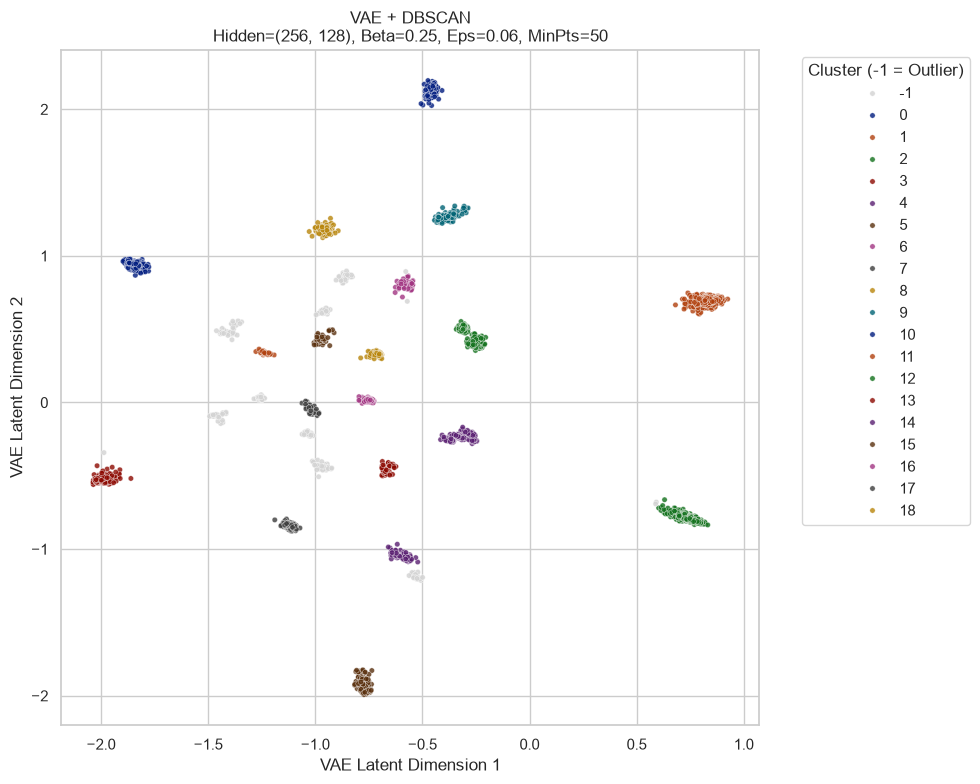

Plot saved to: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\5.vae_dbscan_tuning\final_vae_dbscan_clusters.png


In [39]:
sns.set_theme(
    style="whitegrid"
)

plt.figure(
    figsize=(10, 8)
)

unique_clusters = sorted([
    cluster
    for cluster
    in np.unique(
        final_labels
    )
    if cluster != -1
])

palette = {
    cluster: color
    for cluster, color
    in zip(
        unique_clusters,
        sns.color_palette(
            "dark",
            len(
                unique_clusters
            )
        )
    )
}

palette[-1] = "lightgrey"

sns.scatterplot(
    x=final_embedding[:, 0],
    y=final_embedding[:, 1],
    hue=final_labels,
    palette=palette,
    s=15,
    alpha=0.8
)

plt.xlabel(
    "VAE Latent Dimension 1"
)

plt.ylabel(
    "VAE Latent Dimension 2"
)

plt.title(
    "VAE + DBSCAN\n"
    f"Hidden="
    f"{final_model['Hidden_Layers']}, "
    f"Beta="
    f"{final_model['Beta']}, "
    f"Eps="
    f"{final_eps:.2f}, "
    f"MinPts="
    f"{final_min_samples}"
)

plt.legend(
    title="Cluster (-1 = Outlier)",
    bbox_to_anchor=(
        1.05,
        1
    ),
    loc="upper left"
)

plt.tight_layout()

plot_file = (
    PLOTS_DIR /
    "final_vae_dbscan_clusters.png"
)

plt.savefig(
    plot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Plot saved to:",
    plot_file
)

## Save the Final Cluster Assignments

In [40]:
final_clusters_df = pd.DataFrame({
    ID_COLUMN:
        patient_ids.reset_index(
            drop=True
        ),

    "LATENT_1":
        final_embedding[:, 0],

    "LATENT_2":
        final_embedding[:, 1],

    "Cluster":
        final_labels
})

final_cluster_file = (
    RESULTS_DIR /
    "final_vae_dbscan_clusters.csv"
)

final_clusters_df.to_csv(
    final_cluster_file,
    index=False
)

print(
    "Final cluster assignments "
    "saved successfully."
)

print(
    "Saved to:",
    final_cluster_file
)

display(
    final_clusters_df.head()
)

Final cluster assignments saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\final_vae_dbscan_clusters.csv


,patientunitstayid,LATENT_1,LATENT_2,Cluster
0,151900,-1.851845,0.943556,0
1,165269,-1.416843,-0.075817,-1
2,179269,0.835043,0.699253,1
3,172764,0.832545,0.683643,1
4,215156,0.843825,0.684628,1


## Save the Final Parameter Summary

In [41]:
final_summary = pd.DataFrame({

    "Parameter": [
        "Hidden Layers",
        "Latent Dimension",
        "Learning Rate",
        "Beta",
        "Batch Size",
        "Epochs",
        "Knee Epsilon",
        "DBSCAN Epsilon",
        "MinPts",
        "Number of Clusters",
        "Number of Outliers",
        "Outlier Percentage",
        "Smallest Cluster",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "Value": [
        final_model[
            "Hidden_Layers"
        ],

        int(
            final_model[
                "Latent_Dim"
            ]
        ),

        final_model[
            "Learning_Rate"
        ],

        final_model[
            "Beta"
        ],

        int(
            final_model[
                "Batch_Size"
            ]
        ),

        int(
            final_model[
                "Epochs"
            ]
        ),

        final_model[
            "Knee_Eps"
        ],

        final_eps,

        final_min_samples,

        int(
            final_model[
                "Clusters"
            ]
        ),

        int(
            np.sum(
                final_labels == -1
            )
        ),

        final_model[
            "Outlier_Percentage"
        ],

        int(
            final_model[
                "Smallest_Cluster"
            ]
        ),

        final_model[
            "Silhouette"
        ],

        final_model[
            "Davies_Bouldin"
        ],

        final_model[
            "Calinski_Harabasz"
        ]
    ]
})

display(
    final_summary
)

,Parameter,Value
0,Hidden Layers,"(256, 128)"
1,Latent Dimension,2
2,Learning Rate,0.0008
3,Beta,0.25
4,Batch Size,128
5,Epochs,100
6,Knee Epsilon,0.060641
7,DBSCAN Epsilon,0.06
8,MinPts,50
9,Number of Clusters,19


## Save the Final Parameter Summary CSV

In [42]:
summary_file = (
    RESULTS_DIR /
    "final_vae_dbscan_parameters.csv"
)

final_summary.to_csv(
    summary_file,
    index=False
)

print(
    "Final parameter summary "
    "saved successfully."
)

print(
    "Saved to:",
    summary_file
)

Final parameter summary saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\5.vae_dbscan_tuning\final_vae_dbscan_parameters.csv
